# In-situ MI comparison across five methods

Use this notebook for a **single setting / single experiment**.

It loads:
- SpiderNet edge scores from `SpiderNet_Simulation.py`
- COMMOT edge scores from `COMMOT_Simulation.py`
- NMF-LR edge scores from `NMF_LR_Simulation.py`
- ScCChain raw edge program scores from the external ScCChain result folder
- Spacia raw interaction scores from the external Spacia result folder

Then it renders comparable in-situ plots for the methods you choose.


It first tries precomputed edge-score CSVs for external methods, then falls back to raw Spacia compiled outputs when needed.


In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba

def _load_sim_utils():
    candidate_paths = [
        Path.cwd() / "simulation_benchmark_utils_fixed_v2.py",
        Path.cwd() / "simulation_benchmark_utils_fixed.py",
        Path.cwd() / "simulation_benchmark_utils.py",
        Path("/mnt/data/simulation_benchmark_utils_fixed_v2.py"),
        Path("/mnt/data/simulation_benchmark_utils_fixed.py"),
        Path("/mnt/data/simulation_benchmark_utils.py"),
        Path("/mnt/data/simulation_benchmark_utils (2) (1)(1).py"),
    ]
    for path in candidate_paths:
        if path.is_file():
            spec = importlib.util.spec_from_file_location("simulation_benchmark_utils_runtime", path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            print(f"Loaded simulation utils from: {path}")
            return module
    raise FileNotFoundError("Could not locate simulation_benchmark_utils*.py next to the notebook or in /mnt/data.")

sim_utils = _load_sim_utils()

METHOD_ORDER = sim_utils.METHOD_ORDER
SETTING_LIST = sim_utils.SETTING_LIST
get_local_result_dir = sim_utils.get_local_result_dir
load_method_edge_scores_for_sample = sim_utils.load_method_edge_scores_for_sample

# ------------------------------------------------------------
# 0. Choose one sample
# ------------------------------------------------------------
SETTING_INDEX = 0
EXPERIMENT_INDEX = 18
METHODS_TO_SHOW = METHOD_ORDER.copy()

SHOW_GROUND_TRUTH = True
SELECTION_MODE = "spidernet_sparse_others_legacy"
TOPK_SCALE = 1.0          # used for SpiderNet only
MIN_SCORE_TO_PLOT = None  # used for SpiderNet only
CELL_SIZE = 2
EDGE_LINEWIDTH = 0.8
EDGE_ALPHA_MIN = 0.18
SAVE_FIGURE = True
VERBOSE_LOAD = True

setting_name = SETTING_LIST[SETTING_INDEX]
payload, method_edge_scores = load_method_edge_scores_for_sample(
    setting_idx=SETTING_INDEX,
    experiment_idx=EXPERIMENT_INDEX,
    methods_to_show=METHODS_TO_SHOW,
)
edge_index = payload["edge_index"]
edgemeta_data = payload["edgemeta_data"]
spatial_location = payload["spatial_location"]

print("Resolved data root:", payload.get("data_root"))
print("Loaded methods:", sorted(method_edge_scores.keys()))

if VERBOSE_LOAD:
    for method_name, df in method_edge_scores.items():
        note = getattr(df, "attrs", {}).get("alignment_note", "No alignment note.")
        print(f"[{method_name}] {note}")

if "Spacia" not in method_edge_scores:
    print("[Diagnostic] Spacia is still missing. Check the warning above for the exact path/search failure.")

C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Loaded simulation utils from: D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\Tutorial\Simulation\simulation_benchmark_utils_fixed_v2.py
[Warning] Spacia could not be loaded: Could not find Spacia compiled output for Dropout1 / Experiment_18. Checked both the direct export-style paths used by the benchmark pipeline and broader recursive searches under D:\SpiderNet\Results\Simulation\Spacia and E:\project_SpiderNet\Simulation\Spacia_analysis.
Resolved data root: D:\SpiderNet\Data\Simulation
Loaded methods: ['COMMOT', 'NMF-LR', 'ScCChain', 'SpiderNet']
[SpiderNet] SpiderNet: edge indices aligned to reference via direct_pair_match.
[COMMOT] COMMOT: using the original notebook behavior (raw edge-score CSV without additional re-alignment).
[NMF-LR] NMF-LR: using the original notebook behavior (raw edge-score CSV without additional re-alignment).
[ScCChain] ScCChain: using the original notebook behavior (scores reconstructed directly on the reference edge order).
[Diagnostic] Spacia is still m

In [2]:
# ------------------------------------------------------------
# 1. Method-specific edge scores
# ------------------------------------------------------------
# Edge scores are loaded through
# simulation_benchmark_utils.load_method_edge_scores_for_sample(),
# and are now aligned to the reference simulation edge list before plotting.
# This keeps the in-situ visualization consistent with the benchmarking pipeline
# even if a CSV stores sender/receiver indices in a different convention.

In [3]:

# ------------------------------------------------------------
# 2. Plotting helpers
# ------------------------------------------------------------

MI_COLORS = {
    "MI-1": "#3D3BF3",
    "MI-2": "#FF2929",
}

LEGACY_CMAP = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#3D3BF3", "white", "#FF2929"],
    N=256,
)
LEGACY_NORM = Normalize(vmin=-1, vmax=1)


def build_truth_edge_table():
    truth_df = pd.DataFrame(edge_index, columns=["sender_index", "receiver_index"]).copy()
    truth_df["truth_label"] = edgemeta_data["MetaItype"].astype(str).values
    truth_df = truth_df[truth_df["truth_label"].isin(["MI-1", "MI-2"])].reset_index(drop=True)
    return truth_df


def _normalize_to_unit_interval(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    vmax = np.nanmax(values)
    if (not np.isfinite(vmax)) or vmax <= 0:
        return np.zeros_like(values, dtype=float)
    out = values / vmax
    out[~np.isfinite(out)] = 0.0
    return out


def build_predicted_edge_table_spidernet(edge_scores_df, truth_edge_df, topk_scale=1.0, min_score=None):
    selected_frames = []

    for mi_name in ["MI-1", "MI-2"]:
        scores = edge_scores_df[mi_name].to_numpy(dtype=float)
        k_truth = int((truth_edge_df["truth_label"] == mi_name).sum())
        k_use = max(1, min(scores.shape[0], int(round(k_truth * topk_scale))))

        order = np.argsort(scores)[::-1][:k_use]
        sub = edge_scores_df.iloc[order, :][["sender_index", "receiver_index"]].copy()
        sub["plot_label"] = mi_name
        sub["score"] = scores[order]

        if min_score is not None:
            sub = sub[sub["score"] >= float(min_score)].copy()

        selected_frames.append(sub)

    pred_df = pd.concat(selected_frames, axis=0, ignore_index=True)
    if pred_df.shape[0] == 0:
        return pred_df

    pred_df = pred_df.sort_values("score", ascending=False)
    pred_df = pred_df.drop_duplicates(subset=["sender_index", "receiver_index"], keep="first")
    pred_df = pred_df.reset_index(drop=True)
    pred_df["score_norm"] = _normalize_to_unit_interval(pred_df["score"].to_numpy(dtype=float))
    return pred_df


def build_truth_weighted_scores_legacy(edge_scores_df):
    edge_scores_df = edge_scores_df.copy()
    edge_strength_complex_order_list = []
    edge_order_list = []

    for mi_name in ["MI-1", "MI-2"]:
        truth = (edgemeta_data["MetaItype"].values == mi_name).astype(np.int32)
        scores = edge_scores_df[mi_name].to_numpy(dtype=float)
        scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)

        signed = ((truth - 0.5) * 2.0) * scores
        signed[truth == 0] = -np.abs(signed[truth == 0]) ** 3
        signed[truth == 1] = np.abs(signed[truth == 1]) ** 3

        order = np.argsort(signed)
        edge_order_list.append(edge_scores_df.iloc[order, :][["sender_index", "receiver_index"]])
        edge_strength_complex_order_list.append(signed[order])

    merged_edges = pd.concat(edge_order_list, axis=0, ignore_index=True)
    merged_scores = np.concatenate(edge_strength_complex_order_list, axis=0)
    final_order = np.argsort(merged_scores)
    return merged_edges.iloc[final_order, :].reset_index(drop=True), merged_scores[final_order]


def draw_edge_table(ax, edge_df, label_col, score_col=None):
    if edge_df.shape[0] == 0:
        return

    if score_col is None:
        score_vec = np.ones(edge_df.shape[0], dtype=float)
    else:
        score_vec = edge_df[score_col].to_numpy(dtype=float)

    for row_idx in range(edge_df.shape[0]):
        sender_index = int(edge_df.iloc[row_idx]["sender_index"])
        receiver_index = int(edge_df.iloc[row_idx]["receiver_index"])
        mi_label = str(edge_df.iloc[row_idx][label_col])
        strength = float(score_vec[row_idx])

        color_rgba = to_rgba(MI_COLORS[mi_label], alpha=EDGE_ALPHA_MIN + (1.0 - EDGE_ALPHA_MIN) * strength)
        lw_use = EDGE_LINEWIDTH * (0.65 + 0.85 * strength)

        ax.annotate(
            "",
            xy=(spatial_location[receiver_index, 0], spatial_location[receiver_index, 1]),
            xytext=(spatial_location[sender_index, 0], spatial_location[sender_index, 1]),
            arrowprops=dict(
                arrowstyle="->,head_length=0.05,head_width=0.05",
                color=color_rgba,
                lw=lw_use,
            ),
        )


def draw_edge_scores_legacy(ax, edges_sorted, signed_scores):
    for row_idx in range(edges_sorted.shape[0]):
        sender_index = int(edges_sorted.iloc[row_idx]["sender_index"])
        receiver_index = int(edges_sorted.iloc[row_idx]["receiver_index"])
        edge_color = LEGACY_CMAP(LEGACY_NORM(signed_scores[row_idx]))
        ax.annotate(
            "",
            xy=(spatial_location[receiver_index, 0], spatial_location[receiver_index, 1]),
            xytext=(spatial_location[sender_index, 0], spatial_location[sender_index, 1]),
            arrowprops=dict(
                arrowstyle="->,head_length=0.05,head_width=0.05",
                color=edge_color,
                lw=1.0,
            ),
        )


def plot_ground_truth(ax, truth_edge_df):
    ax.scatter(spatial_location[:, 0], spatial_location[:, 1], c="lightgrey", s=CELL_SIZE)
    draw_edge_table(ax, truth_edge_df, label_col="truth_label")
    ax.set_title("Ground truth")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_method_spidernet(ax, edge_scores_df, truth_edge_df):
    pred_df = build_predicted_edge_table_spidernet(
        edge_scores_df=edge_scores_df,
        truth_edge_df=truth_edge_df,
        topk_scale=TOPK_SCALE,
        min_score=MIN_SCORE_TO_PLOT,
    )

    ax.scatter(spatial_location[:, 0], spatial_location[:, 1], c="lightgrey", s=CELL_SIZE)
    draw_edge_table(ax, pred_df, label_col="plot_label", score_col="score_norm")

    subtitle = f"SpiderNet sparse view | top-{pred_df.shape[0]} edges"
    ax.set_title(subtitle)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_method_legacy(ax, method_name, edge_scores_df):
    edges_sorted, signed_scores = build_truth_weighted_scores_legacy(edge_scores_df)
    ax.scatter(spatial_location[:, 0], spatial_location[:, 1], c="grey", s=2)
    draw_edge_scores_legacy(ax, edges_sorted, signed_scores)
    ax.set_title(f"{method_name}\nlegacy display")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_method(ax, method_name, edge_scores_df, truth_edge_df):
    if method_name == "SpiderNet":
        plot_method_spidernet(ax, edge_scores_df, truth_edge_df)
        strategy = getattr(edge_scores_df, "attrs", {}).get("alignment_strategy", None)
        if strategy is not None:
            ax.set_title(f"SpiderNet\n{strategy} | sparse top-k")
    else:
        plot_method_legacy(ax, method_name, edge_scores_df)


def make_shared_legend(fig):
    handles = [
        Line2D([0], [0], color=MI_COLORS["MI-1"], lw=2, label="MI-1"),
        Line2D([0], [0], color=MI_COLORS["MI-2"], lw=2, label="MI-2"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))


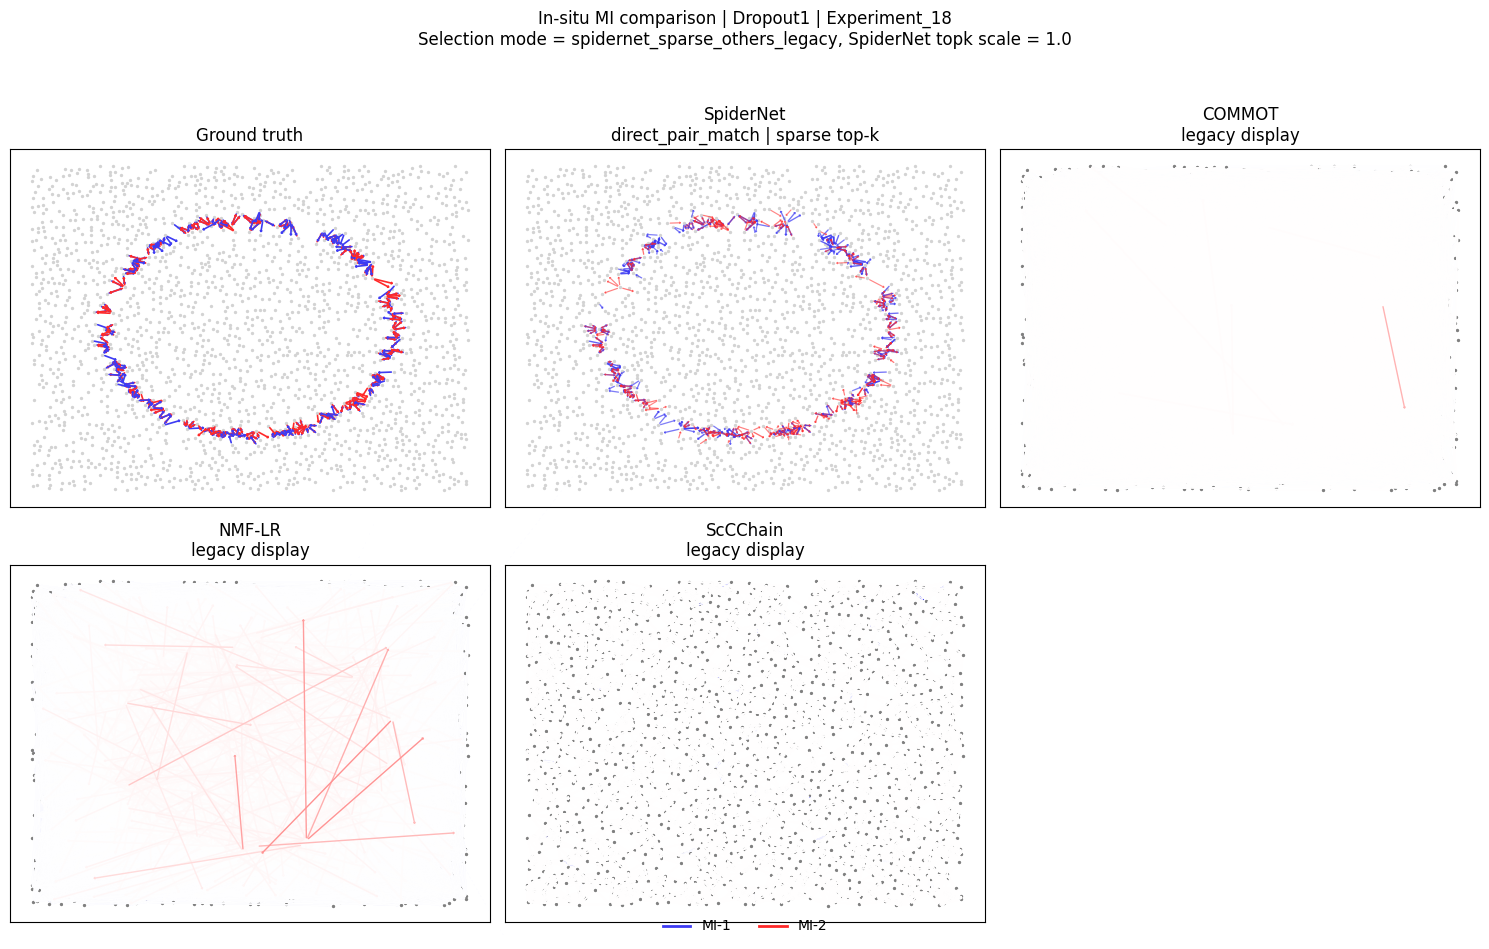

Saved figure to: D:\SpiderNet\Results\Simulation\SpiderNet\Dropout1\Experiment_18\CellFlowMap_Result_Mode_cell_class\Insitu_MIall_compare_five_methods_Dropout1_Experiment_18.pdf


In [4]:
# ------------------------------------------------------------
# 3. Render the selected methods
# ------------------------------------------------------------
selected_methods = [m for m in METHODS_TO_SHOW if m in method_edge_scores]
if len(selected_methods) == 0:
    raise ValueError("No methods were available for plotting.")

truth_edge_df = build_truth_edge_table()

panel_names = selected_methods.copy()
if SHOW_GROUND_TRUTH:
    panel_names = ["Ground truth"] + panel_names

n_panels = len(panel_names)
n_cols = min(3, n_panels)
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for ax in axes.flatten():
    ax.axis("off")

for ax, panel_name in zip(axes.flatten(), panel_names):
    ax.axis("on")
    if panel_name == "Ground truth":
        plot_ground_truth(ax, truth_edge_df)
    else:
        plot_method(ax, panel_name, method_edge_scores[panel_name], truth_edge_df)

make_shared_legend(fig)
fig.suptitle(
    f"In-situ MI comparison | {setting_name} | Experiment_{EXPERIMENT_INDEX}\n"
    f"Selection mode = {SELECTION_MODE}, SpiderNet topk scale = {TOPK_SCALE}",
    y=1.03,
)
fig.tight_layout()
plt.show()

if SAVE_FIGURE:
    out_dir = get_local_result_dir("SpiderNet", setting_name, EXPERIMENT_INDEX)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"Insitu_MIall_compare_five_methods_{setting_name}_Experiment_{EXPERIMENT_INDEX}.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    print("Saved figure to:", out_path)